# Module 1 — Exploration, Nettoyage et Analyse


## 0. Imports & Configuration

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)
SEED = 42

NUMERICAL_FEATURES = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite"]
REGRESSION_TARGET  = "Prix_Revente"
ALL_NUM            = NUMERICAL_FEATURES + [REGRESSION_TARGET]
TARGET             = "Categorie"
CATEGORICAL_FEAT   = "Source"

print("✅ Imports OK")

✅ Imports OK


## 📂 1. Chargement du dataset

In [2]:
df = pd.read_csv("dataset_ProjetML_2026 (1).csv", sep =',',  header =0)

print("=" * 60)
print("APERÇU DU DATASET")
print("=" * 60)
print(f"  Dimensions  : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"  Colonnes    : {list(df.columns)}")
print(f"\n  Types :\n{df.dtypes.to_string()}")
print()
display(df.head(5))
print()
display(df.describe(include="all"))

APERÇU DU DATASET
  Dimensions  : 10500 lignes × 9 colonnes
  Colonnes    : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte']

  Types :
Poids               float64
Volume              float64
Conductivite        float64
Opacite             float64
Rigidite            float64
Prix_Revente        float64
Categorie            object
Source               object
Rapport_Collecte     object



,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
count,9471.000000,9960.000000,9483.000000,9465.000000,9942.000000,9964.000000,9986,9964,10500
unique,NaN,NaN,NaN,NaN,NaN,NaN,4,4,9336
top,NaN,NaN,NaN,NaN,NaN,NaN,Plastique,Collecte_Citoyenne,Ferraille ou métal collecté via la collecte ci...
freq,NaN,NaN,NaN,NaN,NaN,NaN,2795,2644,8
mean,77.796501,144.408079,0.207674,1.160388,5.886643,58.587857,NaN,NaN,NaN
std,127.847433,136.384216,0.378934,5.492723,3.087225,720.059089,NaN,NaN,NaN
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000,NaN,NaN,NaN
25%,19.751538,44.436897,0.000000,0.196410,3.000000,1.393623,NaN,NaN,NaN
50%,39.193029,88.084217,0.000000,0.553484,5.000000,4.135356,NaN,NaN,NaN
75%,130.497561,240.200023,0.000000,1.000000,9.000000,6.781634,NaN,NaN,NaN


## 2. Suppression de la colonne `Source`

> Variable catégorielle nominale supprimée du pipeline de classification.

In [3]:
print("=" * 60)
print("SUPPRESSION DE LA COLONNE SOURCE")
print("=" * 60)

if CATEGORICAL_FEAT in df.columns:
    df = df.drop(columns=[CATEGORICAL_FEAT])
    print(f"✅  Colonne '{CATEGORICAL_FEAT}' supprimée.")
else:
    print(f"⚠️   Colonne '{CATEGORICAL_FEAT}' introuvable.")

print(f"  Colonnes restantes ({len(df.columns)}) : {list(df.columns)}")
print(f"  Dimensions : {df.shape}")

SUPPRESSION DE LA COLONNE SOURCE
✅  Colonne 'Source' supprimée.
  Colonnes restantes (8) : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente', 'Categorie', 'Rapport_Collecte']
  Dimensions : (10500, 8)


## 3. Suppression des lignes où `Categorie` est manquante



In [4]:
print("=" * 60)
print("SUPPRESSION DES LIGNES SANS LABEL Categorie (MNAR)")
print("=" * 60)

n_avant = len(df)
n_nan   = df[TARGET].isnull().sum()
print(f"  Lignes avec Categorie manquante : {n_nan}  ({n_nan/n_avant*100:.1f}%)")

df = df.dropna(subset=[TARGET]).reset_index(drop=True)

print(f"  Avant  : {n_avant} lignes")
print(f"  Après  : {len(df)} lignes  (−{n_avant - len(df)} supprimées)")
print()
display(df[TARGET].value_counts().rename("count").to_frame())

SUPPRESSION DES LIGNES SANS LABEL Categorie (MNAR)
  Lignes avec Categorie manquante : 514  (4.9%)
  Avant  : 10500 lignes
  Après  : 9986 lignes  (−514 supprimées)



,count
Categorie,
Plastique,2795
Verre,2586
Papier,2318
Métal,2287


## 4. Analyse des valeurs manquantes — Qualification MCAR / MAR / MNAR

> On vérifie le mécanisme de manque sur chaque colonne numérique.

ANALYSE DES VALEURS MANQUANTES


,nb_manquants,pct_manquants
Opacite,992,9.93%
Poids,977,9.78%
Conductivite,959,9.60%
Rigidite,530,5.31%
Prix_Revente,514,5.15%
Volume,513,5.14%


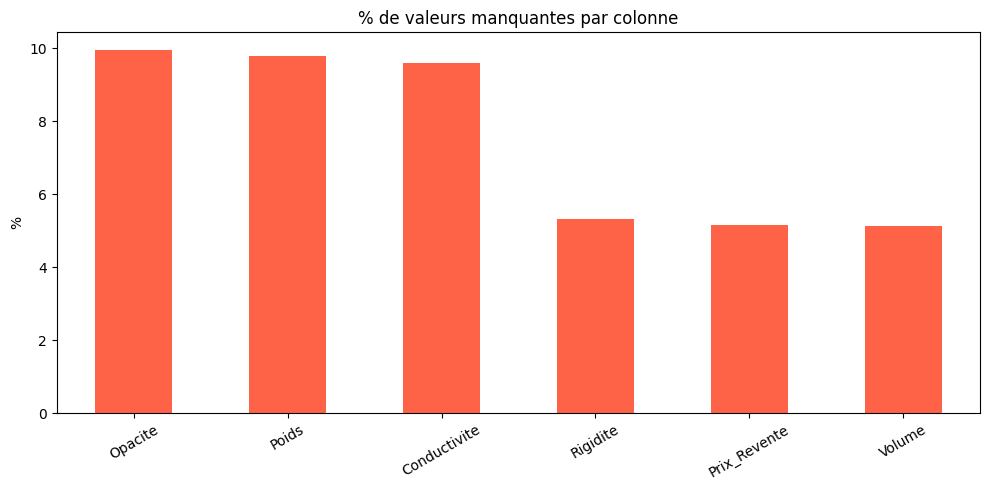


  Qualification MCAR/MAR — variable 'Poids' :


,r,p
Volume,-0.033,0.0014
Conductivite,0.034,0.0011
Opacite,-0.012,0.2603
Rigidite,-0.005,0.6162
Prix_Revente,-0.019,0.0647


  → Corrélation significative avec ['Volume', 'Conductivite'] ⇒ probable MAR
  → Categorie : MNAR (labels non collectés intentionnellement — déjà supprimés)


In [5]:
print("=" * 60)
print("ANALYSE DES VALEURS MANQUANTES")
print("=" * 60)

num_present = [c for c in ALL_NUM if c in df.columns]

missing = pd.DataFrame({
    "nb_manquants" : df.isnull().sum(),
    "pct_manquants": df.isnull().mean() * 100,
}).sort_values("pct_manquants", ascending=False)
missing = missing[missing["nb_manquants"] > 0]
display(missing.style.format({"pct_manquants": "{:.2f}%"}))

# ── Barplot : % de valeurs manquantes par colonne ─────────────
plt.figure(figsize=(10, 5))

if not missing.empty:
    missing["pct_manquants"].plot(kind="bar", color="tomato")
    plt.title("% de valeurs manquantes par colonne")
    plt.ylabel("%")
    plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("outputs/missing_values.png", dpi=120)
plt.show()

# ── Test MCAR sur Poids ───────────────────────────────────────
print("\n  Qualification MCAR/MAR — variable 'Poids' :")
if "Poids" in df.columns:
    ind = df["Poids"].isnull().astype(int)
    corrs = {}
    for col in num_present:
        if col != "Poids":
            nna = df[col].dropna()
            corr, p = stats.pointbiserialr(ind[nna.index], nna)
            corrs[col] = {"r": round(corr,3), "p": round(p,4)}
    display(pd.DataFrame(corrs).T)
    sig = [k for k,v in corrs.items() if v["p"] < 0.05]
    if sig:
        print(f"  → Corrélation significative avec {sig} ⇒ probable MAR")
    else:
        print("  → Aucune corrélation significative ⇒ probable MCAR")
print("  → Categorie : MNAR (labels non collectés intentionnellement — déjà supprimés)")

## 5. Comparaison des 3 stratégies d'imputation

> **Médiane globale** | **KNN Imputer (k=5)** | **IterativeImputer (MICE)**

> Critère de sélection : meilleure **préservation de la variance** (écart-type proche de l'original).

In [6]:
print("=" * 60)
print("COMPARAISON DES STRATÉGIES D'IMPUTATION")
print("=" * 60)

num_present = [c for c in ALL_NUM if c in df.columns]
df_num = df[num_present].copy()

# ── Stratégie A : Médiane globale ─────────────────────────────
imp_med  = SimpleImputer(strategy="median")
df_med   = pd.DataFrame(imp_med.fit_transform(df_num), columns=num_present, index=df_num.index)

# ── Stratégie B : KNN (k=5) ───────────────────────────────────
imp_knn  = KNNImputer(n_neighbors=5)
df_knn   = pd.DataFrame(imp_knn.fit_transform(df_num), columns=num_present, index=df_num.index)

# ── Stratégie C : IterativeImputer ────────────────────────────
imp_iter = IterativeImputer(random_state=SEED, max_iter=10)
df_iter  = pd.DataFrame(imp_iter.fit_transform(df_num), columns=num_present, index=df_num.index)

# ── Tableau écart-types ───────────────────────────────────────
comp_std = pd.DataFrame({
    "Original"        : df_num.std(),
    "Médiane"         : df_med.std(),
    "KNN (k=5)"       : df_knn.std(),
    "IterativeImputer": df_iter.std(),
}).round(4)
print("\nÉcart-types (indicateur de préservation de la variance) :")
display(comp_std)

# ── Tableau moyennes ─────────────────────────────────────────
comp_mean = pd.DataFrame({
    "Original"        : df_num.mean(),
    "Médiane"         : df_med.mean(),
    "KNN (k=5)"       : df_knn.mean(),
    "IterativeImputer": df_iter.mean(),
}).round(4)
print("\nMoyennes :")
display(comp_mean)

# ── Score de préservation : distance à l'écart-type original ──
dist_med  = (comp_std["Médiane"]          - comp_std["Original"]).abs().mean()
dist_knn  = (comp_std["KNN (k=5)"]        - comp_std["Original"]).abs().mean()
dist_iter = (comp_std["IterativeImputer"] - comp_std["Original"]).abs().mean()

scores = pd.Series({"Médiane":dist_med, "KNN (k=5)":dist_knn, "IterativeImputer":dist_iter})
best   = scores.idxmin()
print(f"\nScore (distance std à l'original — plus petit = mieux) :")
display(scores.rename("distance_std").to_frame().style.highlight_min(color="lightgreen"))
print(f"\n🏆 Meilleure stratégie : {best}")

COMPARAISON DES STRATÉGIES D'IMPUTATION

Écart-types (indicateur de préservation de la variance) :


,Original,Médiane,KNN (k=5),IterativeImputer
Poids,129.0222,123.0904,129.8205,124.3654
Volume,136.6335,133.6624,136.1876,135.7092
Conductivite,0.3785,0.3650,0.3764,0.3693
Opacite,5.5171,5.2391,5.5047,5.2361
Rigidite,3.0873,3.0109,3.0899,3.0729
Prix_Revente,724.1624,705.3821,705.6435,705.3649



Moyennes :


,Original,Médiane,KNN (k=5),IterativeImputer
Poids,78.0335,74.2309,79.8559,77.3131
Volume,144.6752,141.7680,144.4925,144.6199
Conductivite,0.2071,0.1872,0.2068,0.2051
Opacite,1.1637,1.1028,1.1836,1.1647
Rigidite,5.8904,5.8432,5.8968,5.8951
Prix_Revente,59.1710,56.3382,56.6503,59.0406



Score (distance std à l'original — plus petit = mieux) :


,distance_std
Médiane,4.675183
KNN (k=5),3.296700
IterativeImputer,4.113867



🏆 Meilleure stratégie : KNN (k=5)


### 5b. Distributions avant / après — visualisation

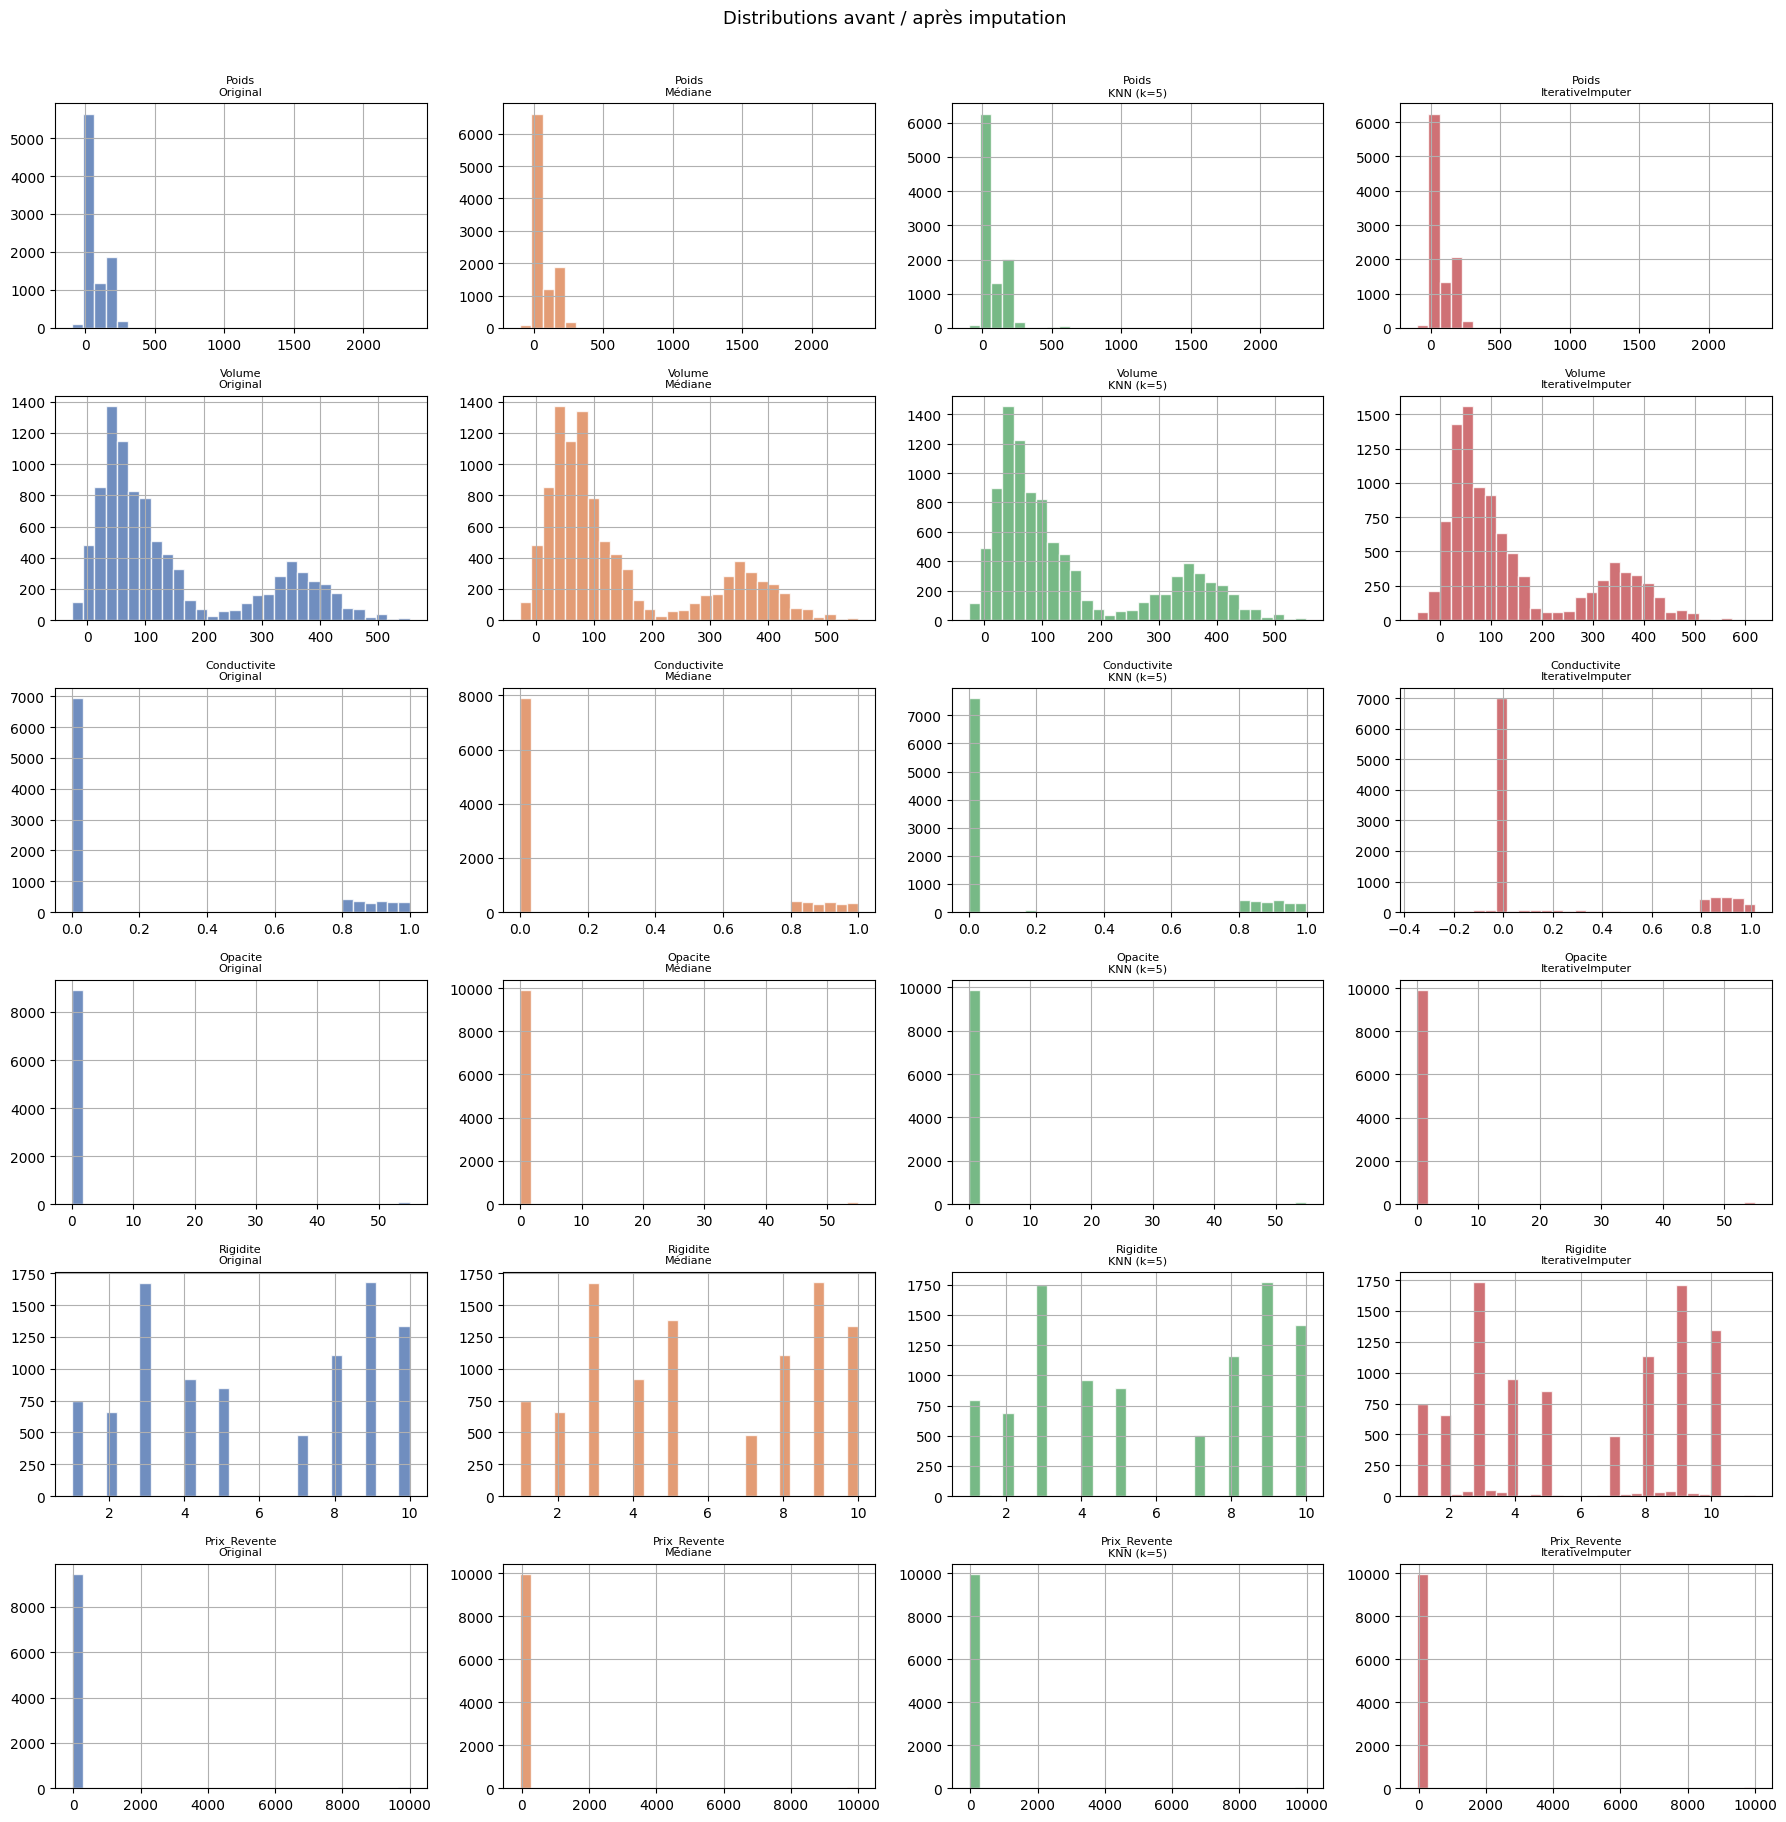

Figure sauvegardée : outputs/imputation_comparison.png


In [7]:
labels_plot   = ["Original", "Médiane", "KNN (k=5)", "IterativeImputer"]
datasets_plot = [df_num, df_med, df_knn, df_iter]
colors        = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(len(num_present), 4, figsize=(18, 3 * len(num_present)))

for i, col in enumerate(num_present):
    for j, (ds, lbl, col_) in enumerate(zip(datasets_plot, labels_plot, colors)):
        ax = axes[i, j] if len(num_present) > 1 else axes[j]
        ds[col].dropna().hist(ax=ax, bins=30, color=col_, alpha=0.8, edgecolor="white")
        ax.set_title(f"{col}\n{lbl}", fontsize=8)
        ax.set_xlabel("")

plt.suptitle("Distributions avant / après imputation", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("outputs/imputation_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : outputs/imputation_comparison.png")

## ✅ 6. Application de la meilleure stratégie — Imputation par groupe de `Categorie`

> On applique la stratégie gagnante **par groupe de `Categorie`** pour préserver les distributions inter-classes.

In [8]:
print("=" * 60)
print("APPLICATION DE L'IMPUTATION PAR GROUPE DE CATEGORIE")
print("=" * 60)
print(f"  Stratégie retenue : {best}")
print()

df_imputed = df.copy()

if best == "Médiane":
    for col in num_present:
        global_med = df_imputed[col].median()
        group_med  = df_imputed.groupby(TARGET)[col].transform("median")
        df_imputed[col] = df_imputed[col].fillna(group_med).fillna(global_med)
    print("  Méthode : médiane calculée par groupe de Categorie")

elif best == "KNN (k=5)":
    # Imputation KNN groupe par groupe
    frames = []
    for cat, grp in df_imputed.groupby(TARGET):
        sub = grp[num_present].copy()
        imp = KNNImputer(n_neighbors=min(5, max(2, len(sub)-1)))
        sub_imp = pd.DataFrame(imp.fit_transform(sub), columns=num_present, index=grp.index)
        grp = grp.copy()
        grp[num_present] = sub_imp
        frames.append(grp)
    df_imputed = pd.concat(frames).sort_index()
    # Repli global si NaN restants
    for col in num_present:
        df_imputed[col] = df_imputed[col].fillna(df[col].median())
    print("  Méthode : KNNImputer appliqué groupe par groupe")

else:  # IterativeImputer
    frames = []
    for cat, grp in df_imputed.groupby(TARGET):
        sub = grp[num_present].copy()
        if sub.isnull().any().any():
            imp = IterativeImputer(random_state=SEED, max_iter=5)
            sub_imp = pd.DataFrame(imp.fit_transform(sub), columns=num_present, index=grp.index)
            grp = grp.copy()
            grp[num_present] = sub_imp
        frames.append(grp)
    df_imputed = pd.concat(frames).sort_index()
    for col in num_present:
        df_imputed[col] = df_imputed[col].fillna(df[col].median())
    print("  Méthode : IterativeImputer appliqué groupe par groupe")

print()
nan_restants = df_imputed[num_present].isnull().sum().sum()
print(f"  NaN restants après imputation : {nan_restants}")
print("✅ Imputation terminée")

print("\n  Médianes par groupe utilisées :")
display(df.groupby(TARGET)[num_present].median().round(3))

APPLICATION DE L'IMPUTATION PAR GROUPE DE CATEGORIE
  Stratégie retenue : KNN (k=5)

  Méthode : KNNImputer appliqué groupe par groupe

  NaN restants après imputation : 0
✅ Imputation terminée

  Médianes par groupe utilisées :


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
Categorie,,,,,,
Métal,61.713,120.794,0.897,1.000,9.0,18.494
Papier,14.717,32.681,0.000,1.000,2.0,0.741
Plastique,29.056,58.049,0.000,0.401,4.0,2.893
Verre,181.875,356.919,0.000,0.106,9.0,5.422


## 📦 7. Détection et traitement des Outliers

> **IQR** (robuste) + **Z-score** (paramétrique). Traitement par **Winsorisation (capping IQR ×1.5)**.

DÉTECTION ET TRAITEMENT DES OUTLIERS


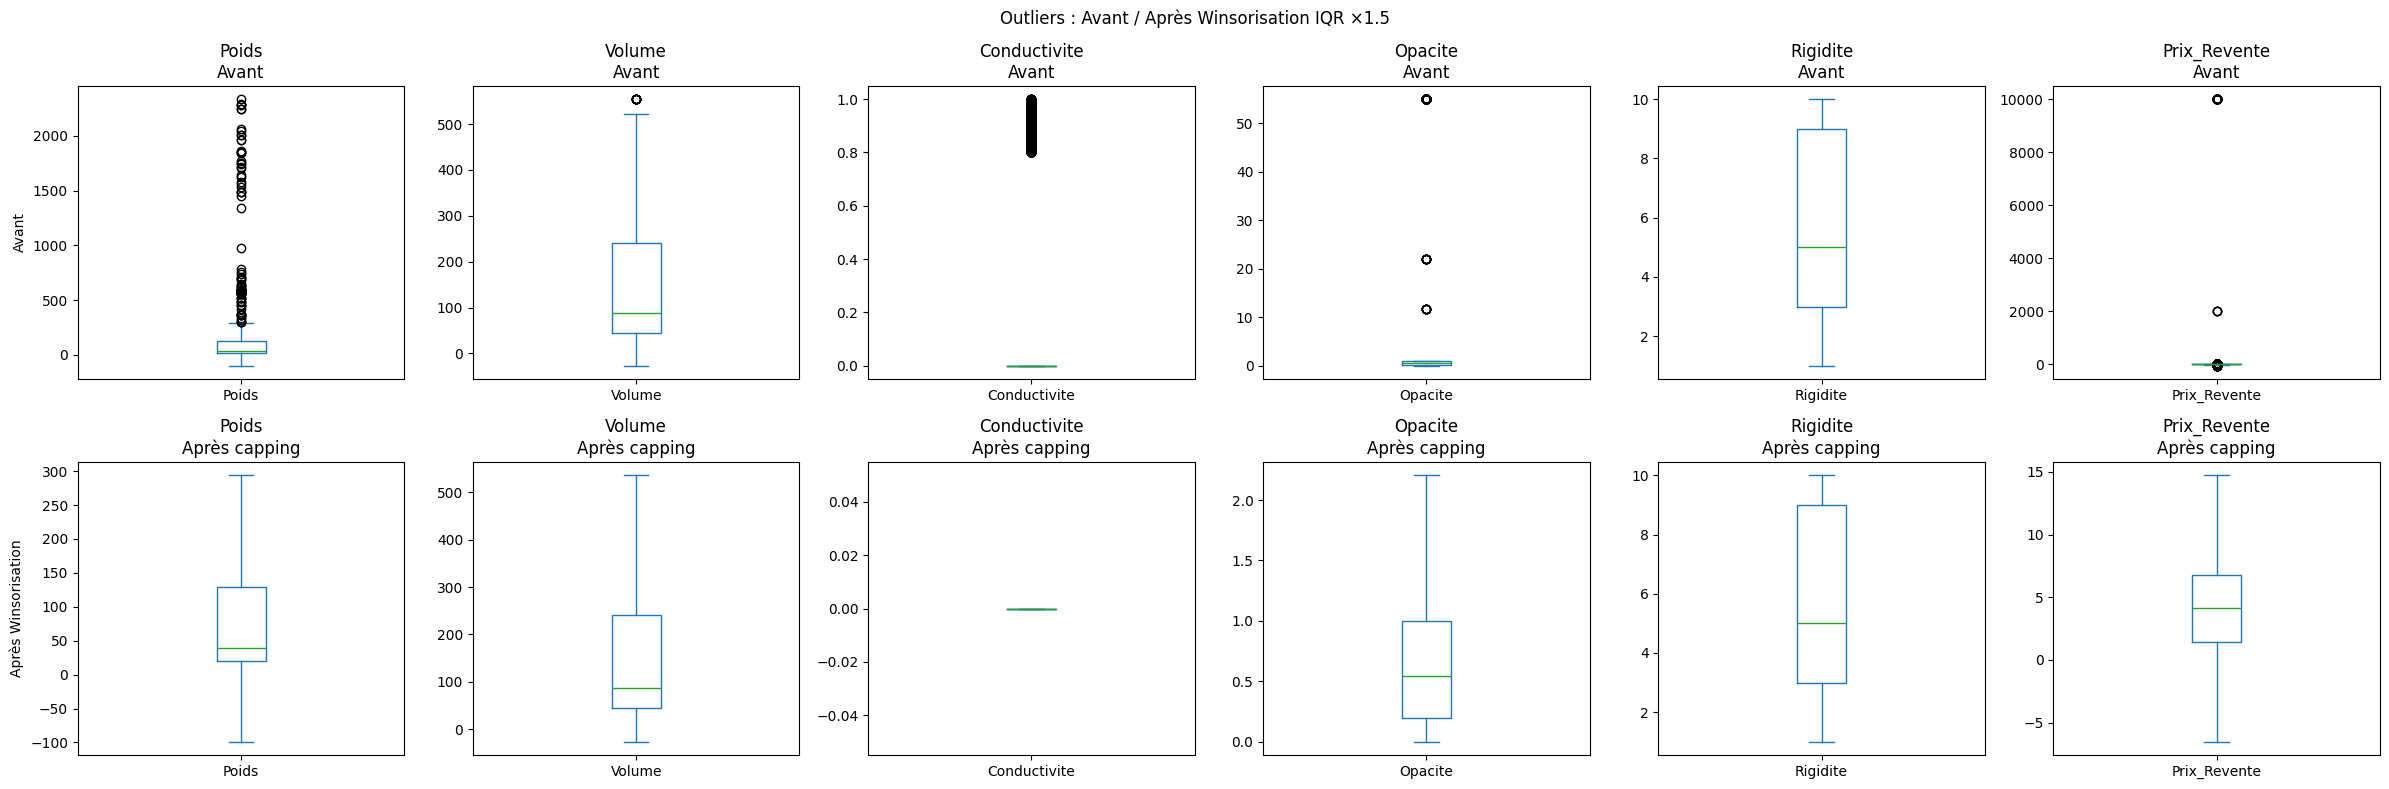

,Outliers IQR,Outliers Z>3,Borne basse (IQR),Borne haute (IQR)
Colonne,,,,
Poids,119,105,-144.618,293.901
Volume,11,11,-250.532,536.052
Conductivite,2287,0,0.000,0.000
Opacite,117,110,-1.008,2.205
Rigidite,0,0,-6.000,18.000
Prix_Revente,1741,50,-6.525,14.726



✅ Winsorisation appliquée — aucune ligne supprimée


In [9]:
print("=" * 60)
print("DÉTECTION ET TRAITEMENT DES OUTLIERS")
print("=" * 60)

df_clean = df_imputed.copy()
summary  = []

fig, axes = plt.subplots(2, len(num_present), figsize=(4 * len(num_present), 8))

for i, col in enumerate(num_present):
    series = df_clean[col].dropna()

    # IQR
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR    = Q3 - Q1
    lb_iqr = Q1 - 1.5 * IQR
    ub_iqr = Q3 + 1.5 * IQR
    n_iqr  = ((series < lb_iqr) | (series > ub_iqr)).sum()

    # Z-score
    n_z = (np.abs(stats.zscore(series)) > 3).sum()

    summary.append({
        "Colonne"          : col,
        "Outliers IQR"     : n_iqr,
        "Outliers Z>3"     : n_z,
        "Borne basse (IQR)": round(lb_iqr, 3),
        "Borne haute (IQR)": round(ub_iqr, 3),
    })

    # Boxplots avant / après
    df_clean[col].plot(kind="box", ax=axes[0, i], title=f"{col}\nAvant")
    df_clean[col].clip(lower=lb_iqr, upper=ub_iqr).plot(
        kind="box", ax=axes[1, i], title=f"{col}\nAprès capping")

    # Application capping :remplace les outliers par les bornes
    df_clean[col] = df_clean[col].clip(lower=lb_iqr, upper=ub_iqr)

axes[0, 0].set_ylabel("Avant")
axes[1, 0].set_ylabel("Après Winsorisation")
plt.suptitle("Outliers : Avant / Après Winsorisation IQR ×1.5", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/outliers_treatment.png", dpi=120)
plt.show()

display(pd.DataFrame(summary).set_index("Colonne"))
print("\n✅ Winsorisation appliquée — aucune ligne supprimée")

## 📊 8. Exploration visuelle (EDA)

> Distribution de la cible, matrice de corrélation, pairplot.

ANALYSE EXPLORATOIRE (EDA)


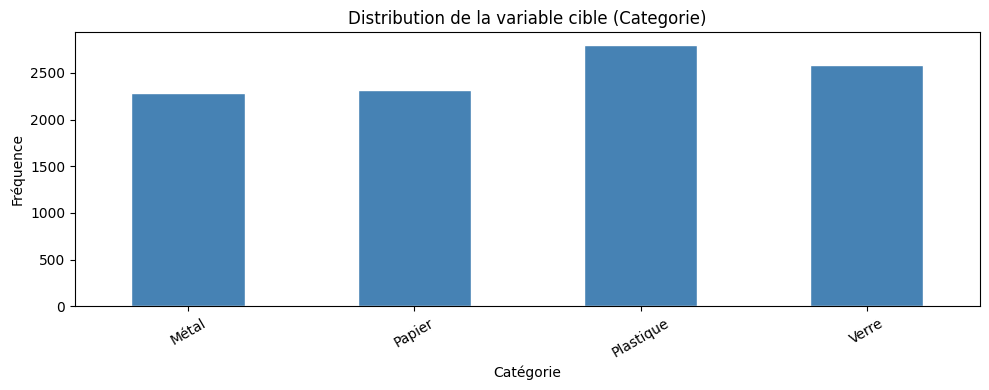

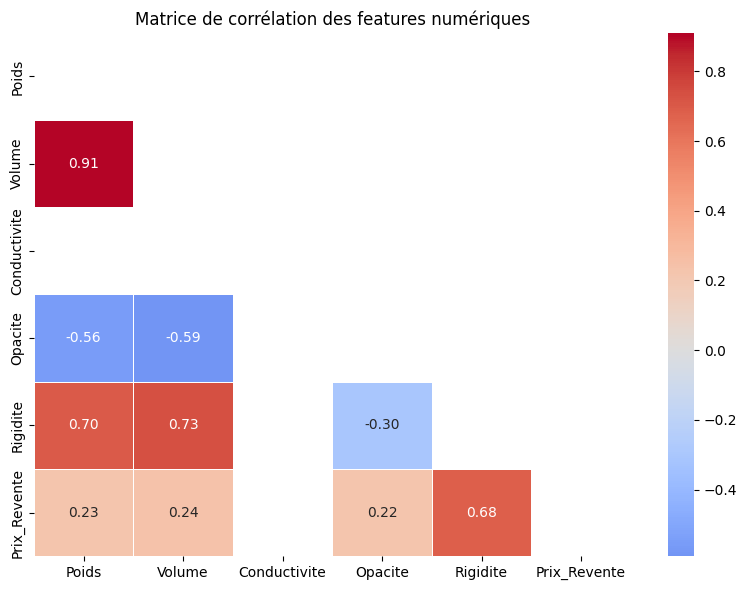

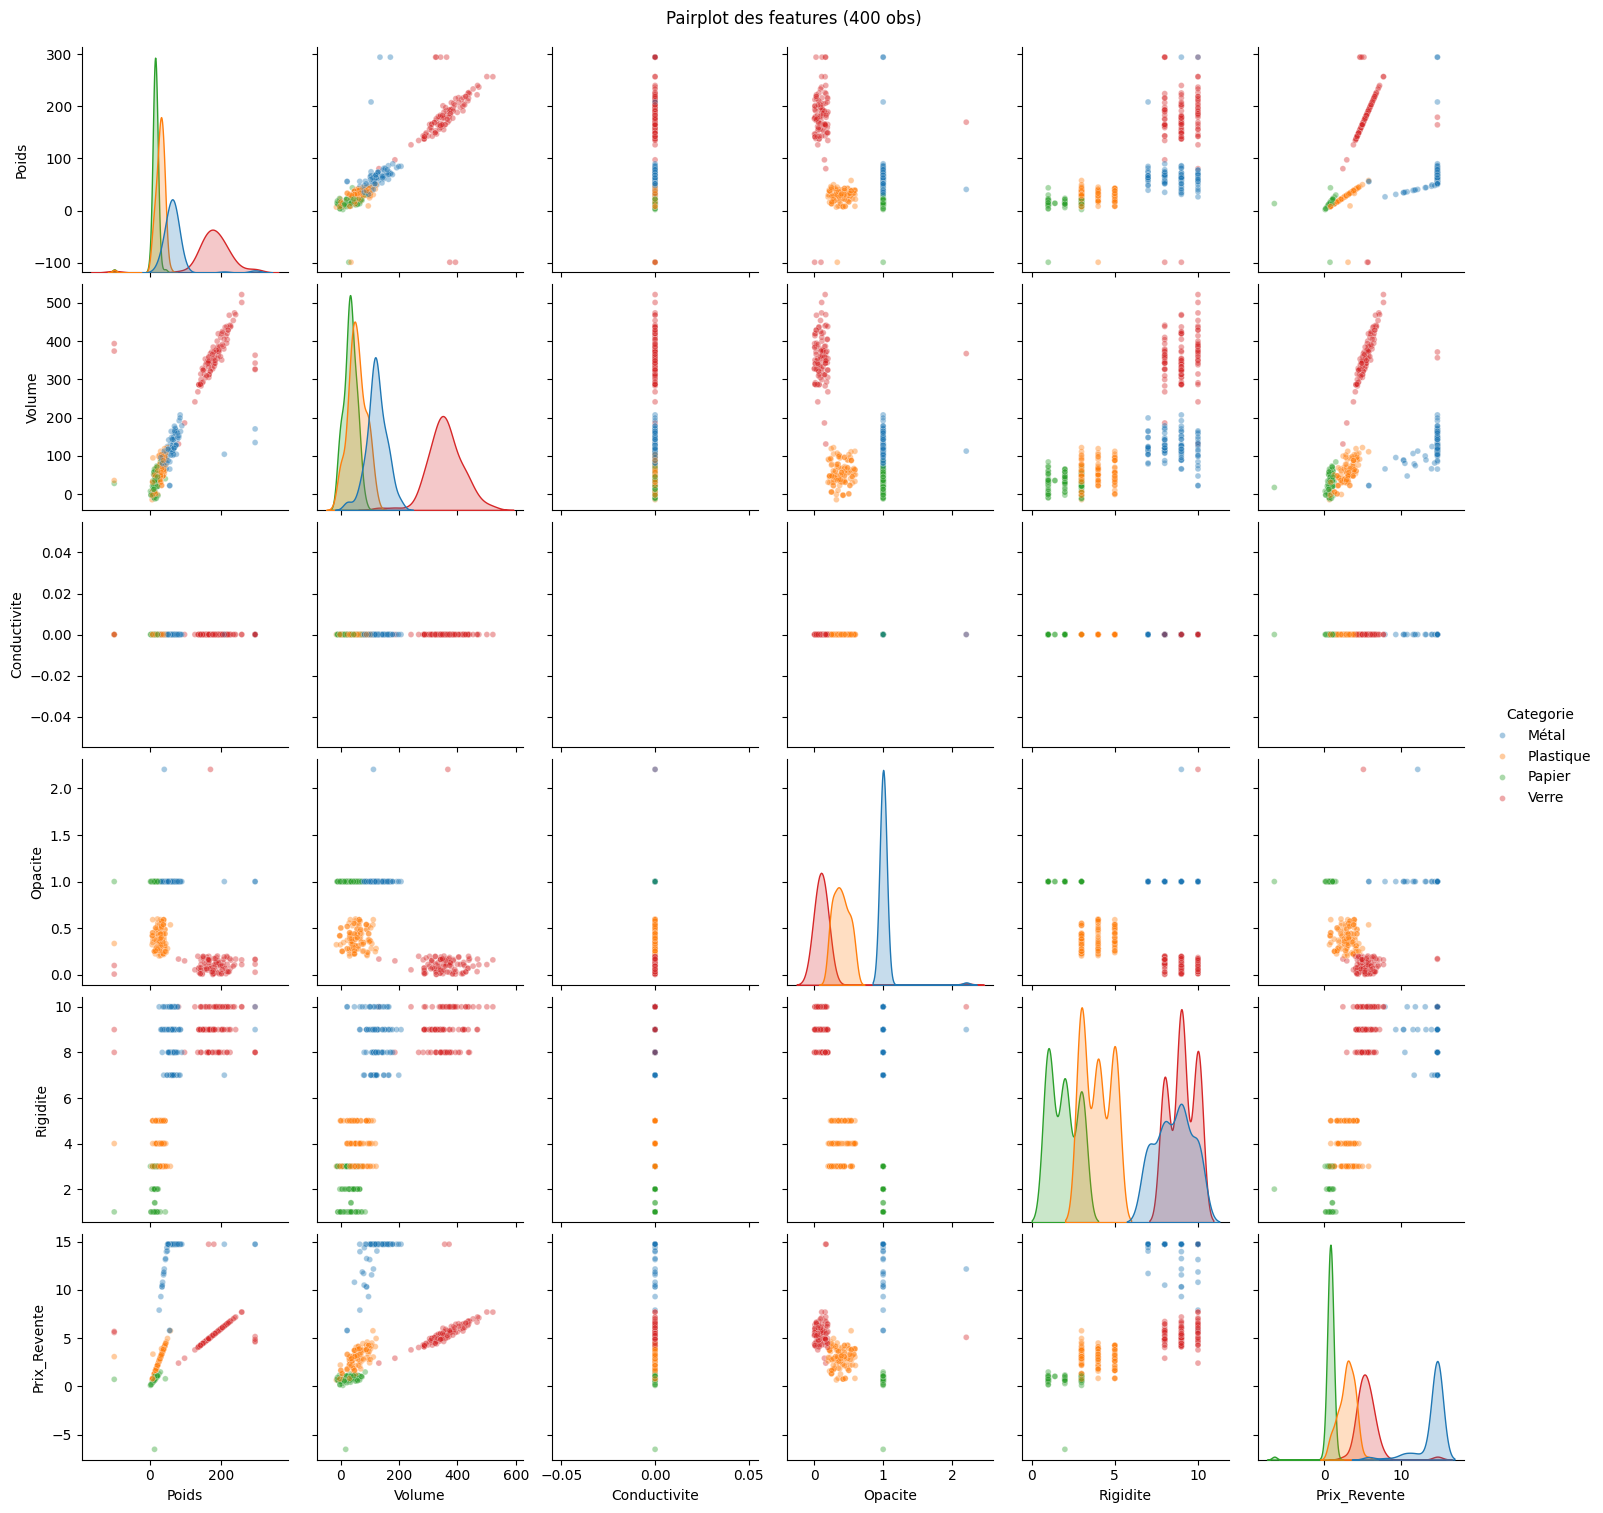

Figures sauvegardées : outputs/


In [10]:
print("=" * 60)
print("ANALYSE EXPLORATOIRE (EDA)")
print("=" * 60)

# Distribution cible
fig, ax = plt.subplots(figsize=(10, 4))
df_clean[TARGET].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Distribution de la variable cible (Categorie)")
ax.set_xlabel("Catégorie")
ax.set_ylabel("Fréquence")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("outputs/target_distribution.png", dpi=120)
plt.show()

# Matrice de corrélation
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_clean[num_present].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax, linewidths=0.5)
ax.set_title("Matrice de corrélation des features numériques")
plt.tight_layout()
plt.savefig("outputs/correlation_matrix.png", dpi=120)
plt.show()

# Pairplot (échantillon 400)
sample = df_clean[num_present + [TARGET]].copy()
if len(sample) > 400:
    sample = sample.sample(400, random_state=SEED)
g = sns.pairplot(sample, hue=TARGET, diag_kind="kde",
                 plot_kws={"alpha": 0.4, "s": 18})
g.fig.suptitle("Pairplot des features (400 obs)", y=1.01)
g.savefig("outputs/pairplot.png", dpi=100)
plt.show()
print("Figures sauvegardées : outputs/")

## ⚖️ 9. Feature Engineering — Normalisation / Standardisation

> Comparaison **StandardScaler | MinMaxScaler | RobustScaler**.
> **Choix retenu : StandardScaler** (adapté aux modèles basés sur la distance).

FEATURE ENGINEERING — SCALING


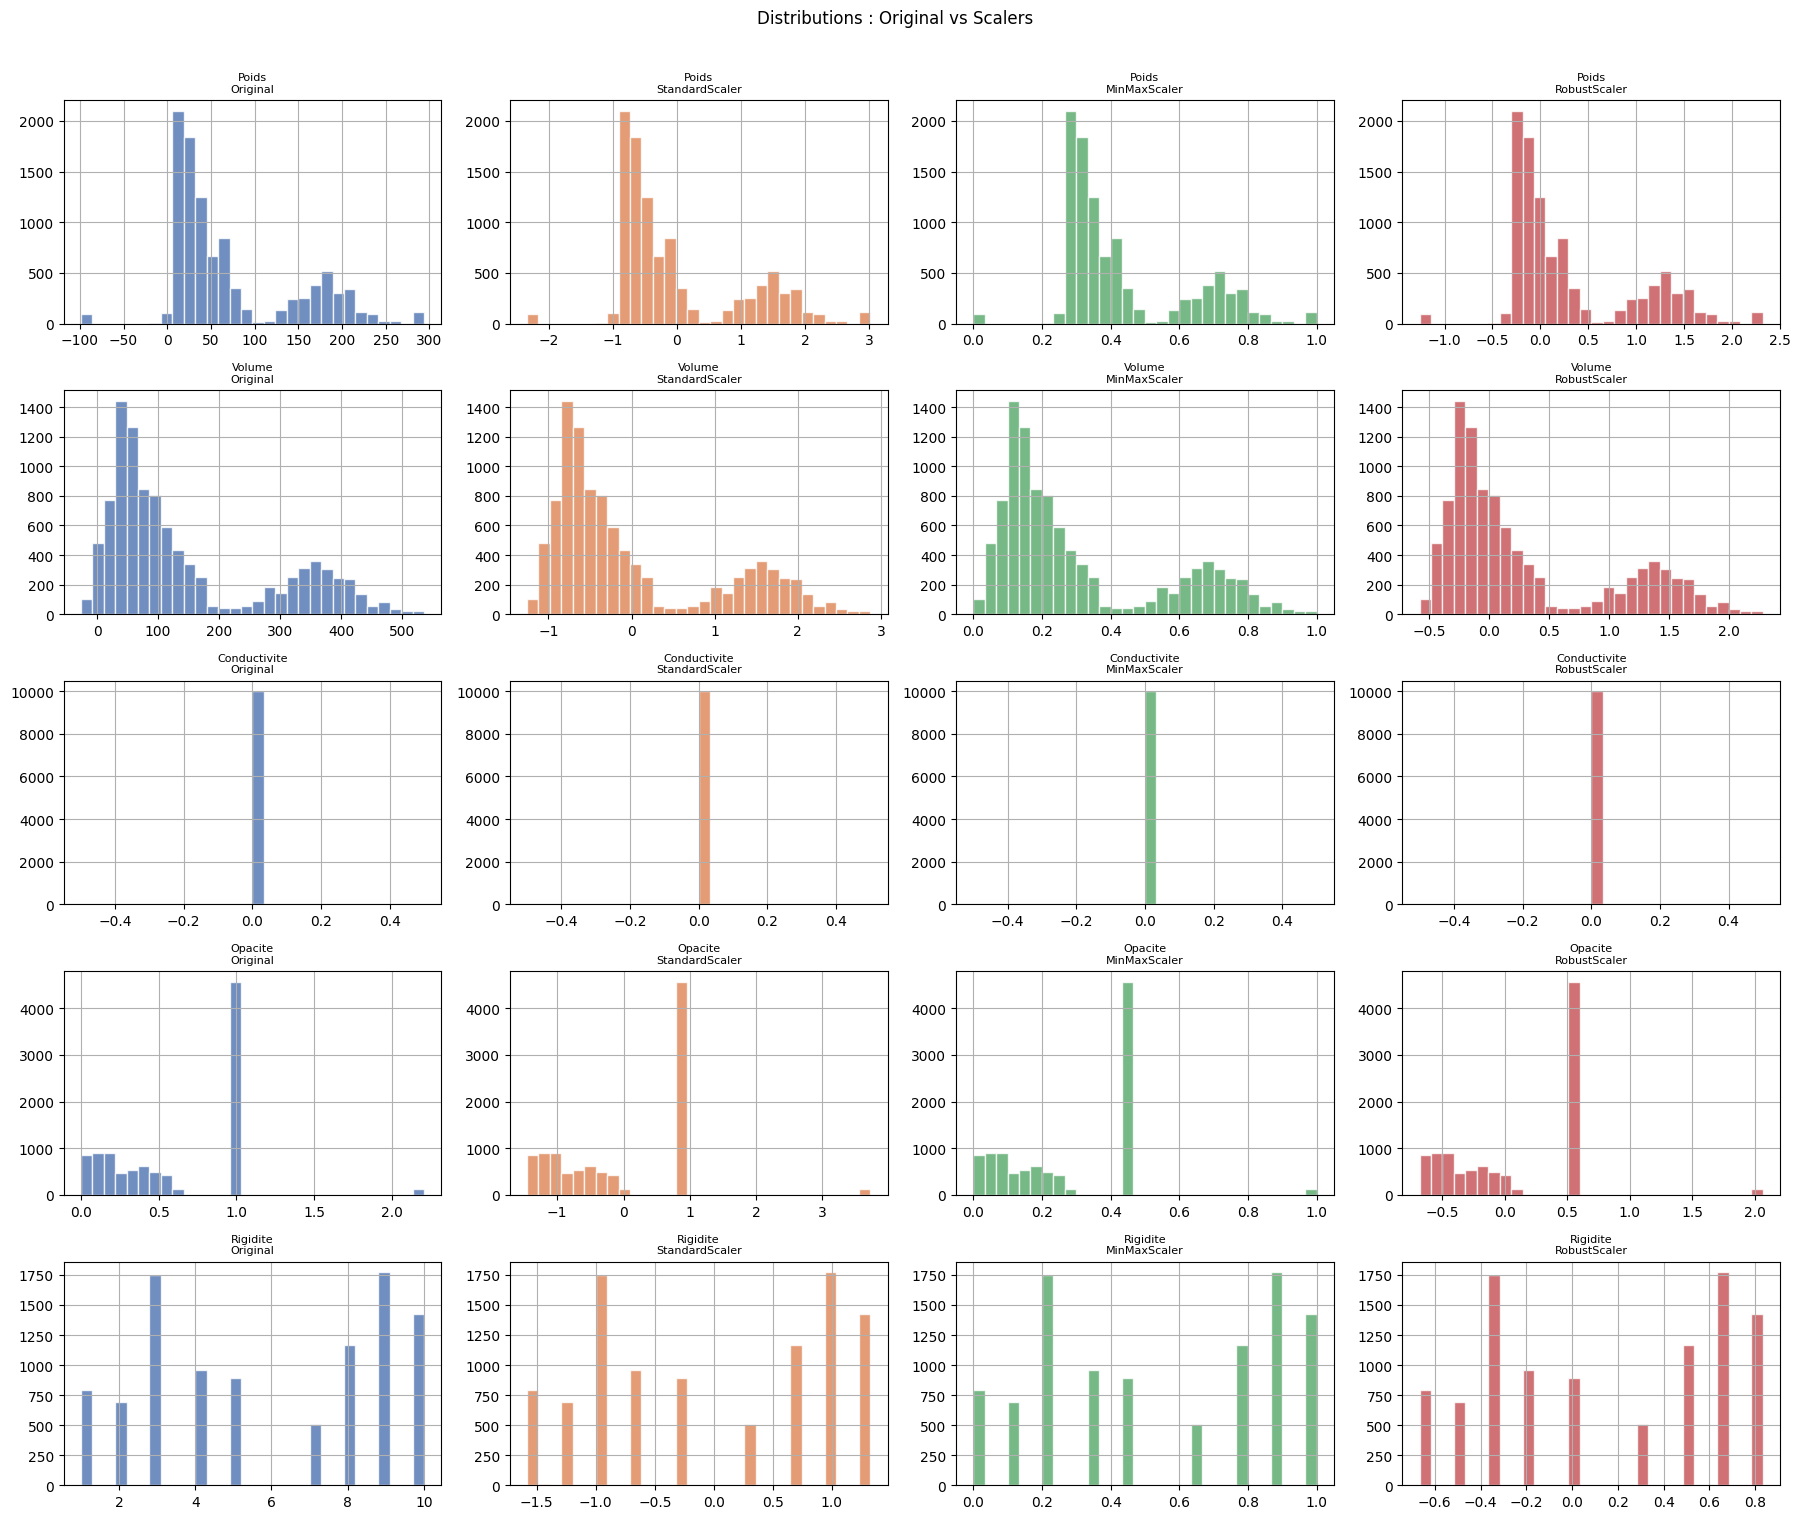


  Colonnes standardisées (StandardScaler) : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite']
  Justification : StandardScaler est adapté aux algorithmes basés sur la distance
  (SVM, KNN, Régression). RobustScaler à préférer si outliers résiduels.



,Poids,Volume,Conductivite,Opacite,Rigidite
count,9986.000,9986.000,9986.0,9986.000,9986.000
mean,-0.000,-0.000,0.0,0.000,0.000
std,1.000,1.000,0.0,1.000,1.000
min,-2.338,-1.257,0.0,-1.456,-1.583
25%,-0.718,-0.734,0.0,-0.994,-0.936
50%,-0.452,-0.416,0.0,-0.171,-0.290
75%,0.777,0.708,0.0,0.893,1.003
max,3.020,2.871,0.0,3.723,1.326



✅ Standardisation appliquée


In [11]:
print("=" * 60)
print("FEATURE ENGINEERING — SCALING")
print("=" * 60)

num_scale = [c for c in NUMERICAL_FEATURES if c in df_clean.columns]

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler"  : MinMaxScaler(),
    "RobustScaler"  : RobustScaler(),
}

# ── Comparaison visuelle ─────────────────────────────────────
raw_data = df_clean[num_scale].copy()
fig, axes = plt.subplots(len(num_scale), 4, figsize=(18, 3 * len(num_scale)))
titles    = ["Original"] + list(scalers.keys())
colors_sc = ["#4C72B0","#DD8452","#55A868","#C44E52"]

for i, col in enumerate(num_scale):
    raw = raw_data[[col]].dropna()
    datasets_sc = [raw[col]]
    for sc in scalers.values():
        datasets_sc.append(pd.Series(sc.fit_transform(raw).ravel()))
    for j, (dat, ttl, c_) in enumerate(zip(datasets_sc, titles, colors_sc)):
        ax = axes[i, j] if len(num_scale) > 1 else axes[j]
        dat.hist(ax=ax, bins=30, color=c_, alpha=0.8, edgecolor="white")
        ax.set_title(f"{col}\n{ttl}", fontsize=8)

plt.suptitle("Distributions : Original vs Scalers", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("outputs/scaling_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Application StandardScaler ────────────────────────────────
df_scaled = df_clean.copy()
scaler_final = StandardScaler()
df_scaled[num_scale] = scaler_final.fit_transform(df_clean[num_scale])

print(f"\n  Colonnes standardisées (StandardScaler) : {num_scale}")
print("  Justification : StandardScaler est adapté aux algorithmes basés sur la distance")
print("  (SVM, KNN, Régression). RobustScaler à préférer si outliers résiduels.\n")
display(df_scaled[num_scale].describe().round(3))
print("\n✅ Standardisation appliquée")

## 🔢 10. Encodage de la variable cible `Categorie` — LabelEncoder

> `Categorie` → entiers 0..N-1 via `LabelEncoder`.

In [12]:
print("=" * 60)
print("ENCODAGE DE LA VARIABLE CIBLE")
print("=" * 60)

df_encoded = df_scaled.copy()
le = LabelEncoder()
df_encoded["Categorie_encoded"] = le.fit_transform(df_encoded[TARGET])

target_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"  Mapping LabelEncoder : {target_mapping}")
print(f"  Lignes encodées      : {len(df_encoded)}")
print(f"  Shape finale         : {df_encoded.shape}")
print()
display(df_encoded[[TARGET, "Categorie_encoded"]].value_counts().reset_index()
        .sort_values("Categorie_encoded").reset_index(drop=True))
print("\n✅ Encodage terminé")

ENCODAGE DE LA VARIABLE CIBLE
  Mapping LabelEncoder : {'Métal': 0, 'Papier': 1, 'Plastique': 2, 'Verre': 3}
  Lignes encodées      : 9986
  Shape finale         : (9986, 9)



,Categorie,Categorie_encoded,count
0,Métal,0,2287
1,Papier,1,2318
2,Plastique,2,2795
3,Verre,3,2586



✅ Encodage terminé


## ✂️ 11. Split stratifié 70 / 15 / 15

> `stratify=y` garantit la même distribution de classes dans chaque sous-ensemble.

SPLIT STRATIFIÉ 70 / 15 / 15
  Train      :  6990 lignes  (70.0%)
  Validation :  1498 lignes  (15.0%)
  Test       :  1498 lignes  (15.0%)


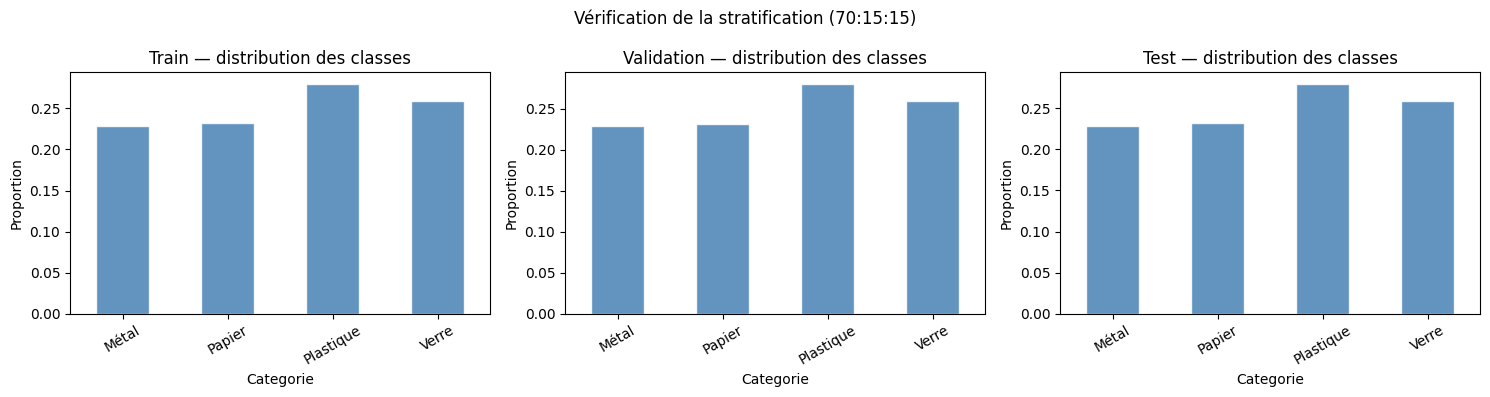


✅ Split terminé


In [13]:
print("=" * 60)
print("SPLIT STRATIFIÉ 70 / 15 / 15")
print("=" * 60)

y = df_encoded["Categorie_encoded"]
n = len(df_encoded)

X_train, X_temp, y_train, y_temp = train_test_split(
    df_encoded, y, test_size=0.30, stratify=y, random_state=SEED)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f"  Train      : {len(X_train):>5} lignes  ({len(X_train)/n*100:.1f}%)")
print(f"  Validation : {len(X_val):>5} lignes  ({len(X_val)/n*100:.1f}%)")
print(f"  Test       : {len(X_test):>5} lignes  ({len(X_test)/n*100:.1f}%)")

# Vérification distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (sdf, name) in zip(axes, [(X_train,"Train"),(X_val,"Validation"),(X_test,"Test")]):
    sdf[TARGET].value_counts(normalize=True).sort_index().plot(
        kind="bar", ax=ax, color="steelblue", alpha=0.85, edgecolor="white")
    ax.set_title(f"{name} — distribution des classes")
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Vérification de la stratification (70:15:15)", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/split_stratification.png", dpi=120)
plt.show()
print("\n✅ Split terminé")

## 📋 12. Résumé final du pipeline

In [14]:
print("=" * 60)
print("RÉSUMÉ PIPELINE MODULE 1")
print("=" * 60)
print(f"  Source supprimée             ✅")
print(f"  Lignes Categorie NaN retirées ✅  ({n_avant - len(df)} lignes)")
print(f"  Stratégie imputation retenue : {best}  ✅")
print(f"  Winsorisation IQR ×1.5       ✅")
print(f"  Scaling StandardScaler       ✅")
print(f"  LabelEncoder Categorie       ✅")
print(f"  Split 70/15/15 stratifié     ✅")
print()
print(f"  Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")
print(f"  Shape dataset final : {df_encoded.shape}")
print(f"  Mapping classes     : {target_mapping}")

RÉSUMÉ PIPELINE MODULE 1
  Source supprimée             ✅
  Lignes Categorie NaN retirées ✅  (514 lignes)
  Stratégie imputation retenue : KNN (k=5)  ✅
  Winsorisation IQR ×1.5       ✅
  Scaling StandardScaler       ✅
  LabelEncoder Categorie       ✅
  Split 70/15/15 stratifié     ✅

  Train : 6990 | Val : 1498 | Test : 1498
  Shape dataset final : (9986, 9)
  Mapping classes     : {'Métal': 0, 'Papier': 1, 'Plastique': 2, 'Verre': 3}


In [15]:
# ── SAUVEGARDER À LA FIN DU MODULE 1 ──────────────────────────
df_clean.to_csv("outputs/full_cleaned.csv", index=False)
print("✅ Données sauvegardées dans outputs/full_cleaned.csv")

✅ Données sauvegardées dans outputs/full_cleaned.csv
